# 箱型圖 Box Plot：不只看平均，還要看生活中的落差


## 開場活動：九張午餐收據排成一列

![](./assets/九張午餐收據排成一列.png)


# 第一部分：主要使用 Matplotlib（10 例）

從一組原始數字開始，先核對四分位數與鬚，再逐步加入比較、橫向圖、平均數、清理政策、樣本數與已彙總資料。預設都用 `whis=1.5`，改規則的地方會另外標示。


### 範例：九次午餐看懂第一個箱子

資料：[datasets/01_九次午餐花費.csv](datasets/01_九次午餐花費.csv)  
獨立程式：[examples/01_九次午餐看懂第一個箱子.py](examples/01_九次午餐看懂第一個箱子.py)  
練習解答：[solutions/01_練習解答.py](solutions/01_練習解答.py)


規劃午餐預算時，除了問平均多少，也想知道平常多落在哪個區間，以及有沒有偶爾花得比較多的那次。這個小資料可以手算，適合對照箱型圖每個零件。

**一列代表：** 小安一次一人份午餐的付款金額。  
**範圍、單位與樣本：** 九次已記錄午餐，單位元；不代表全體學員的花費。

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("./datasets/九次午餐花費.csv", encoding="utf-8-sig")
# df
values = pd.to_numeric(df["金額"], errors="coerce") ### 將金額轉成數值
sorted_values=np.sort(values)
q1,median,q3=np.quantile(values,[0.25,0.5,0.75],method='linear')
iqr=q3-q1
print('排序：',sorted_values)
print('Q1、中位數、Q3：',q1,median,q3)
print('IQR：',iqr,'圍籬：',q1-1.5*iqr,q3+1.5*iqr)

排序： [ 60  70  80  80  90 100 110 120 160]
Q1、中位數、Q3： 80.0 90.0 110.0
IQR： 30.0 圍籬： 35.0 155.0


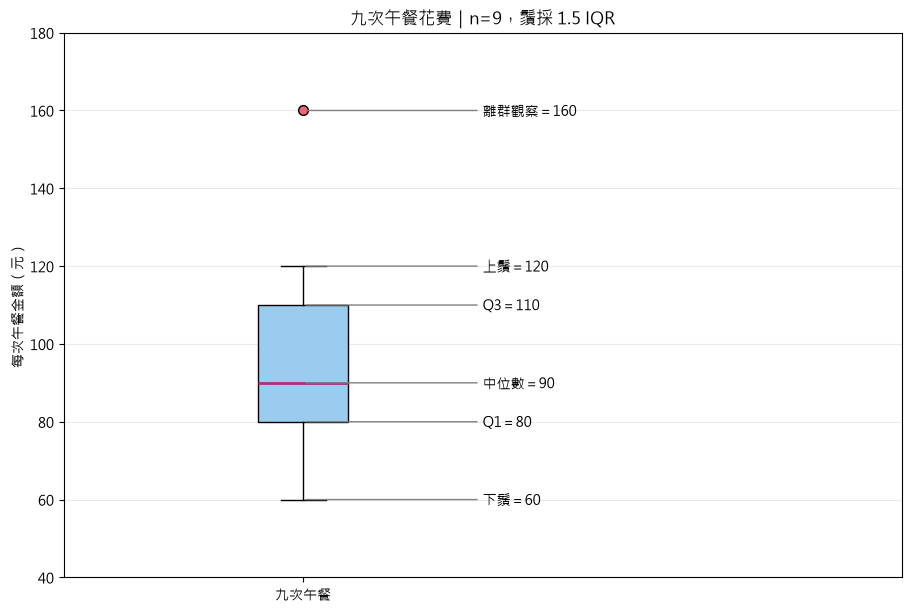

In [ ]:
import matplotlib.pyplot as plt


### 繪製箱型圖
with plt.style.context("default"):

    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

    # 建立 9 × 6 吋的畫布
    fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")

    # 繪製箱型圖
    result = ax.boxplot(
        values, # 要繪製的數值資料
        tick_labels=["九次午餐"], # X 軸類別名稱
        whis=1.5, # 鬚延伸至 1.5 × IQR 範圍內最遠的資料點
        patch_artist=True, # 讓箱子可以填入背景顏色
        boxprops={"facecolor": "#99CCEE"}, # 箱子的填滿顏色
        medianprops={"color": "#AA3377", "linewidth": 2}, # 中位數線條樣式
        flierprops={"marker": "o", "markerfacecolor": "#EE6677", "markersize": 7} # 離群值樣式
    )

    # 標示 Q1、中位數、Q3、上下鬚與離群值
    for y, label in [
        (80, "Q1＝80"),
        (90, "中位數＝90"),
        (110, "Q3＝110"),
        (120, "上鬚＝120"),
        (60, "下鬚＝60"),
        (160, "離群觀察＝160")
    ]:
        ax.annotate(
            label, # 顯示的文字
            xy=(1, y), # 箭頭指向的位置
            xytext=(1.3, y), # 文字顯示的位置
            va="center", # 文字垂直置中
            fontsize=10, # 文字大小
            arrowprops={"arrowstyle": "-", "color": "gray"} # 連接資料點與文字的線條
        )

    # 設定 X、Y 軸顯示範圍
    ax.set_xlim(0.6, 2)
    ax.set_ylim(40, 180)

    # 設定圖表標題與 Y 軸名稱
    ax.set(
        title="九次午餐花費｜n=9，鬚採 1.5 IQR",
        ylabel="每次午餐金額（元）"
    )

    ax.grid(axis="y", alpha=0.25) # 顯示 Y 軸方向的輔助格線
    plt.show()

### 範例：同樣等五分鐘哪家比較穩

資料：[datasets/03_兩店取餐等待.csv](datasets/03_兩店取餐等待.csv)  
獨立程式：[examples/03_同樣等五分鐘哪家比較穩.py](examples/03_同樣等五分鐘哪家比較穩.py)  
練習解答：[solutions/03_練習解答.py](solutions/03_練習解答.py)

### 生活任務：這張圖可以幫我們做什麼？

午休時間有限，兩家店中位數都五分鐘，你可能更關心會不會突然等很久。比較箱子跨度，能把只說「差不多」的印象轉成具體的分散資訊。

**一列代表：** 某店一次完成取餐的等待時間，每店九次。  
**範圍、單位與樣本：** 兩家店各 9 筆，單位分鐘；非隨機試驗，條件未必相同。


In [ ]:
import pandas as pd

df = pd.read_csv("./datasets/兩店取餐等待.csv", encoding="utf-8-sig")
df

,紀錄編號,店家,分鐘
0,巷口店01,巷口店,3
1,巷口店02,巷口店,4
2,巷口店03,巷口店,4
3,巷口店04,巷口店,5
4,巷口店05,巷口店,5
5,巷口店06,巷口店,6
6,巷口店07,巷口店,6
7,巷口店08,巷口店,7
8,巷口店09,巷口店,8
9,轉角店01,轉角店,1


In [8]:
order=['巷口店','轉角店']
# 依照 order 的店家順序，取出各店家的「分鐘」資料並轉成 NumPy 陣列
groups=[df.loc[df['店家']==name,'分鐘'].to_numpy() for name in order]
groups

[array([3, 4, 4, 5, 5, 6, 6, 7, 8]),
 array([ 1,  2,  3,  5,  5,  8, 12, 15, 20])]

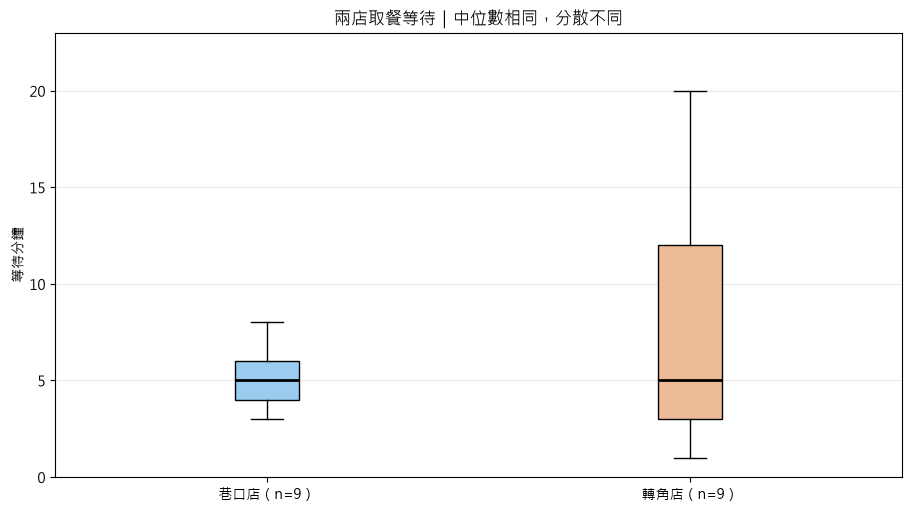

In [9]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig,ax=plt.subplots(figsize=(9,5),layout='constrained')
	result=ax.boxplot(groups,tick_labels=[f'{name}（n=9）' for name in order],whis=1.5,
					patch_artist=True,medianprops={'color':'black','linewidth':2})
	for box,color in zip(result['boxes'],['#99CCEE','#EEBB99']):
		box.set_facecolor(color)
	ax.set(title='兩店取餐等待｜中位數相同，分散不同',ylabel='等待分鐘')
	ax.set_ylim(0,23)
	ax.grid(axis='y',alpha=0.25)
	plt.show()

### 範例：偶爾大帳單怎麼拉高平均

資料：[datasets/05_九個月水電瓦斯.csv](datasets/05_九個月水電瓦斯.csv)  
獨立程式：[examples/05_偶爾大帳單怎麼拉高平均.py](examples/05_偶爾大帳單怎麼拉高平均.py)  


In [14]:
import pandas as pd

df = pd.read_csv("./datasets/九個月水電瓦斯.csv", encoding="utf-8-sig")
values = pd.to_numeric(df["金額"], errors="coerce") ### 將金額轉成數值
df

,月份代號,金額
0,M01,800
1,M02,850
2,M03,900
3,M04,920
4,M05,950
5,M06,980
6,M07,1000
7,M08,1050
8,M09,2400


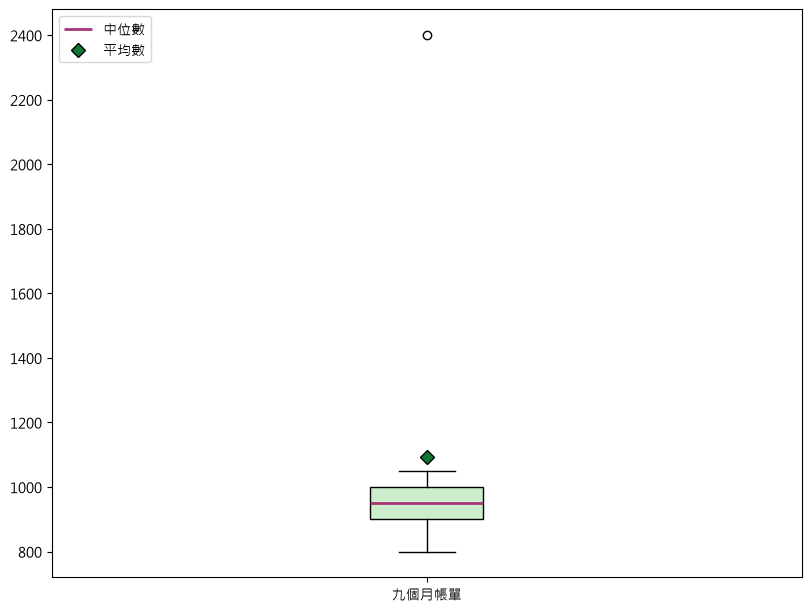

In [22]:
import matplotlib.pyplot as plt

with plt.style.context("default"):
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig,ax=plt.subplots(figsize=(8,6),layout='constrained')
	result = ax.boxplot(
		values,
		tick_labels=["九個月帳單"],
		whis=1.5,
		showmeans=True,
		patch_artist=True,
		boxprops={"facecolor": "#CCEECC"},
		medianprops={"color": "#AA3377", "linewidth": 2},
		meanprops={
			"marker": "D",
			"markerfacecolor": "#117733",
			"markeredgecolor": "black",
			"markersize": 7
		}
	)

	# 使用箱型圖本身的中位數與平均數物件建立圖例
	ax.legend(
		[result["medians"][0], result["means"][0]], # 取得中位數線與平均數標記
		["中位數", "平均數"],
		loc="upper left"
	)
	plt.show()

### 補充：ax.boxplot()箱型圖各個部件的繪圖物件

| Key        | 代表什麼        | 一組資料通常有幾個 |
| ---------- | ----------- | --------: |
| `boxes`    | 箱子(Q1～Q3)   |         1 |
| `medians`  | 中位數線        |         1 |
| `whiskers` | 上鬚、下鬚的線     |         2 |
| `caps`     | 上鬚、下鬚末端的小橫線 |         2 |
| `fliers`   | 離群值         |         1 |
| `means`    | 平均數         |         1 |

```py
print(result.keys())
# dict_keys(['whiskers', 'caps', 'boxes', 'medians', 'fliers', 'means'])
```

### 範例：鬚的規則變了判讀也要變

資料：[datasets/09_十次排隊等待.csv](datasets/09_十次排隊等待.csv)  
獨立程式：[examples/09_鬚的規則變了判讀也要變.py](examples/09_鬚的規則變了判讀也要變.py)  


不同報告的箱型圖可能使用不同鬚定義。一張有兩個點，另一張沒有點，未必代表資料改善；先看 whis 規則，才能公平比較。

**一列代表：** 一次完成排隊的等待分鐘。  
**範圍、單位與樣本：** 十次排隊，三張圖使用相同資料，只改鬚的規則。

In [29]:
import pandas as pd

df = pd.read_csv("./datasets/十次排隊等待.csv", encoding="utf-8-sig")
values = pd.to_numeric(df["分鐘"], errors="coerce") # 將「分鐘」欄轉成數值
df

,紀錄編號,分鐘
0,R01,5
1,R02,6
2,R03,7
3,R04,8
4,R05,9
5,R06,10
6,R07,11
7,R08,12
8,R09,24
9,R10,45


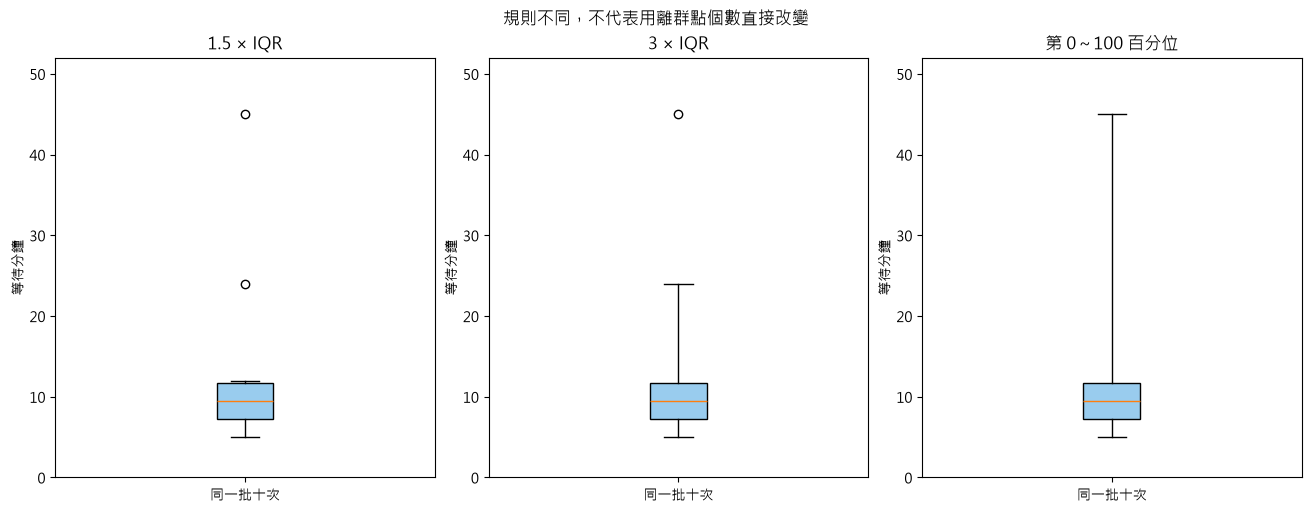

In [35]:
import matplotlib.pyplot as plt

### 比較不同 whis 規則
with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, axes = plt.subplots(1, 3, figsize=(13, 5), layout="constrained")

    # 儲存每張箱型圖回傳的繪圖物件
    results = []

    # 分別使用 1.5 × IQR、3 × IQR、0～100 百分位
    for ax, rule, title in zip(
        axes,
        [1.5, 3, (0, 100)],
        ["1.5 × IQR", "3 × IQR", "第 0～100 百分位"]
    ):
        result = ax.boxplot(
            values, # 使用相同的等待時間資料
            tick_labels=["同一批十次"], # X 軸類別名稱
            whis=rule, # 設定箱型圖上下鬚的判定規則
            patch_artist=True, # 允許設定箱子的填滿顏色
            boxprops={"facecolor": "#99CCEE"} # 箱子的填滿顏色
        )

        results.append(result) # 保存這張箱型圖的繪圖物件

        ax.set(
            title=title,
            ylabel="等待分鐘"
        )

        ax.set_ylim(0, 52)

    # 整張圖的共同標題
    fig.suptitle("規則不同，不代表用離群點個數直接改變")

    plt.show()

# 第二部分：使用 Seaborn

Seaborn 適合直接讀「一列一筆觀察」的長表。`sns.boxplot(data=df, x='分類', y='數值')` 依 x 分組，把各組 y 值的分布畫出來。它不是把每組 y 加總，也不是把 x 文字計數。

### 範例：平日假日午餐先從長表開始

資料：[datasets/11_平假日午餐明細.csv](datasets/11_平假日午餐明細.csv)  
獨立程式：[examples/11_平日假日午餐先從長表開始.py](examples/11_平日假日午餐先從長表開始.py)



平日常吃工作附近，假日偶爾聚餐，花費分布可能不同。Seaborn 可以直接從長表讀取日別與金額，不必先把兩類拆成不同 Python 清單。

**一列代表：** 同一位虛構人物的一次一人份午餐，包含平日或假日類別。  
**範圍、單位與樣本：** 各12次，單位元；假日分類為題目提供的觀察標記。

In [37]:
import pandas as pd

order=['平日','假日']
df = pd.read_csv("./datasets/平假日午餐明細.csv", encoding="utf-8-sig")
df.head()

,紀錄編號,日別,金額
0,平日01,平日,60
1,平日02,平日,65
2,平日03,平日,70
3,平日04,平日,70
4,平日05,平日,75


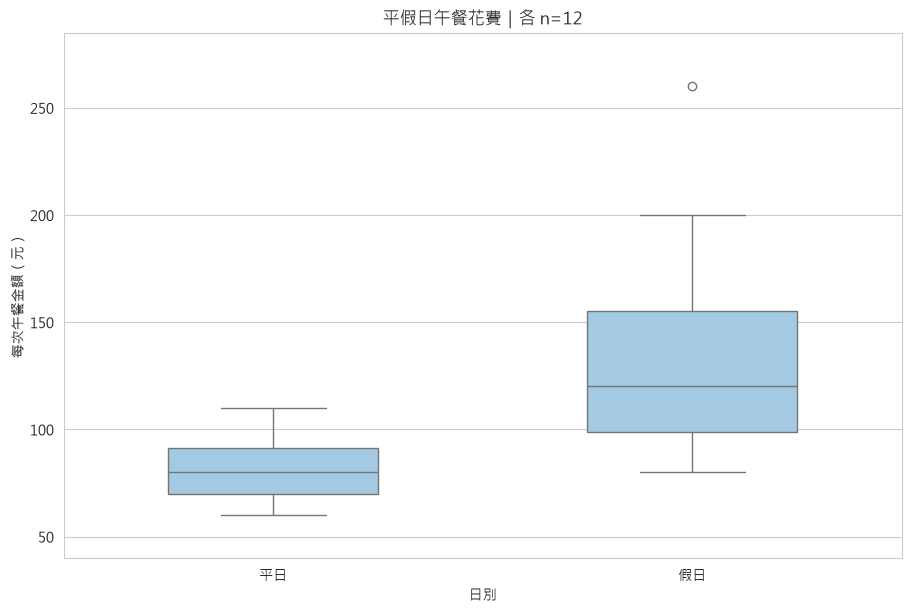

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig,ax=plt.subplots(figsize=(9,6),layout='constrained')
	sns.boxplot(data=df,x='日別',y='金額',order=order,color='#99CCEE',whis=1.5,width=0.5,ax=ax)
	ax.set(title='平假日午餐花費｜各 n=12',xlabel='日別',ylabel='每次午餐金額（元）',ylim=(40,285))
	plt.show()

### 範例：交通方式依中位數排隊

資料：[datasets/12_四種通勤方式.csv](datasets/12_四種通勤方式.csv)  
獨立程式：[examples/12_交通方式依中位數排隊.py](examples/12_交通方式依中位數排隊.py)  

交通方式名稱長，改用橫向箱型，按本批中位數由短到長排列，可以快速看到典型時間排序。同時提醒學生：資料排序不是永久的交通工具排名。

**一列代表：** 一次完整單程通勤觀察，方式可能來自不同條件的路程。  
**範圍、單位與樣本：** 四種方式各8次，單位分鐘；不視為同距離隨機比較。

In [41]:
import pandas as pd

df = pd.read_csv("./datasets/四種通勤方式.csv", encoding="utf-8-sig")
medians=df.groupby('交通方式')['分鐘'].median().sort_values()
order=medians.index.tolist()
medians, order

(交通方式
 走路到教室      14.5
 騎車含找停車位    16.5
 捷運含步行轉乘    25.0
 公車含步行轉乘    32.5
 Name: 分鐘, dtype: float64,
 ['走路到教室', '騎車含找停車位', '捷運含步行轉乘', '公車含步行轉乘'])

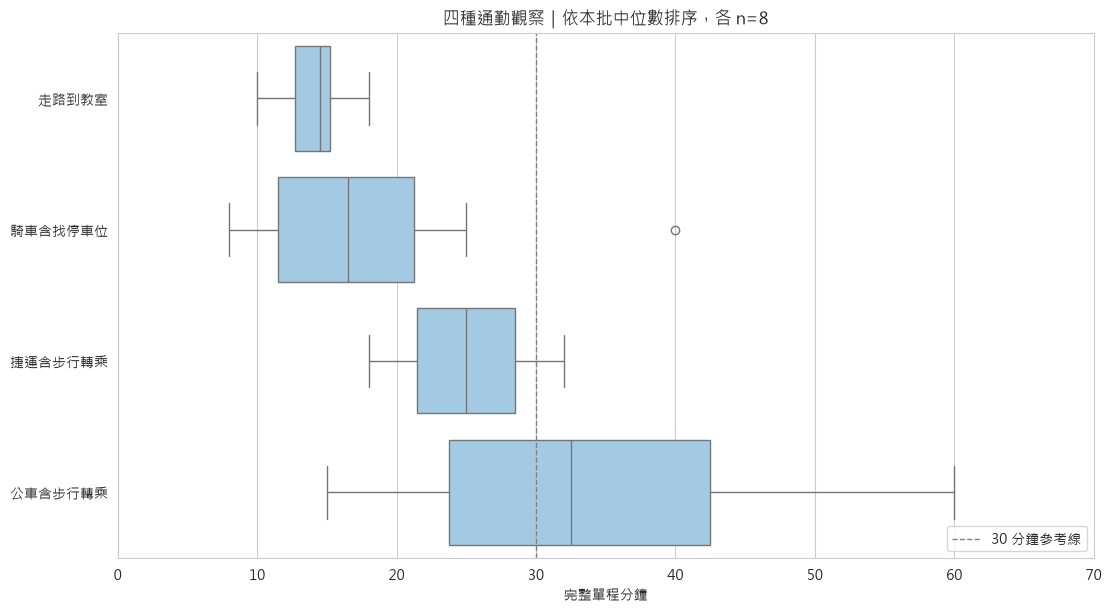

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig,ax=plt.subplots(figsize=(11,6),layout='constrained')
	sns.boxplot(data=df,y='交通方式',x='分鐘',order=order,color='#99CCEE',whis=1.5,ax=ax)
	ax.set(title='四種通勤觀察｜依本批中位數排序，各 n=8',xlabel='完整單程分鐘',ylabel='',xlim=(0,70))
	ax.axvline(30,color='gray',linestyle='--',linewidth=1,label='30 分鐘參考線')
	ax.legend(loc='lower right')
	plt.show()


### 範例：現場與預訂再分平假日

資料：[datasets/13_取餐方式與日別.csv](datasets/13_取餐方式與日別.csv)  
獨立程式：[examples/13_現場與預訂再分平假日.py](examples/13_現場與預訂再分平假日.py)  

只比較現場和預訂，可能把平日與假日的差異混在一起。加入第二分類後，可以看同一方式在不同日別的分布，也練習正確閱讀圖例與並排箱子。

**一列代表：** 一筆完成取餐的等待，含方式與日別兩個分類。  
**範圍、單位與樣本：** 四種組合各8筆，共32筆；皆從抵達取餐點開始計時。

In [44]:
import pandas as pd

order=['現場','預訂']
hue_order=['平日','假日']
palette={'平日':'#4477AA','假日':'#EE8866'}

df = pd.read_csv("./datasets/取餐方式與日別.csv", encoding="utf-8-sig")
table=df.groupby(['取餐方式','日別'])['等待分鐘'].agg(n='size',中位數='median')
table

n  中位數
取餐方式 日別        
現場   假日  8  9.0
     平日  8  4.5
預訂   假日  8  4.0
     平日  8  2.5

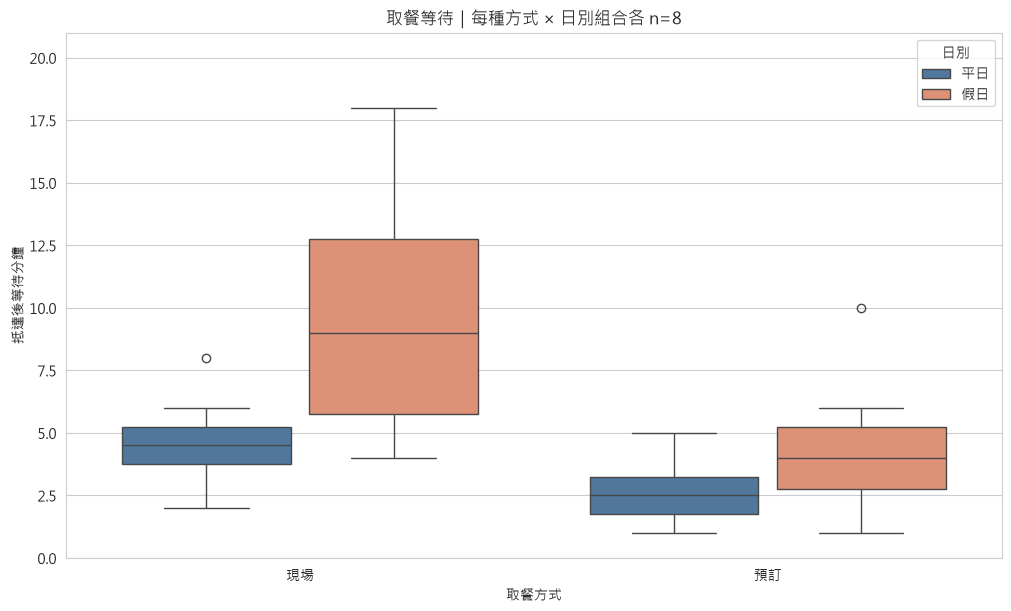

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig,ax=plt.subplots(figsize=(10,6),layout='constrained')
	sns.boxplot(data=df,x='取餐方式',y='等待分鐘',hue='日別',order=order,
				hue_order=hue_order,palette=palette,whis=1.5,dodge=True,gap=0.1,ax=ax)
	ax.set(title='取餐等待｜每種方式 × 日別組合各 n=8',xlabel='取餐方式',ylabel='抵達後等待分鐘',ylim=(0,21))
	ax.legend(title='日別')
	plt.show()

### 範例：箱型加原始點看見重複價格

資料：[datasets/14_三種午餐方式價格.csv](datasets/14_三種午餐方式價格.csv)  
獨立程式：[examples/14_箱型加原始點看見重複價格.py](examples/14_箱型加原始點看見重複價格.py)  


箱子看不出多少筆剛好同價，也可能把小樣本細節藏起來。疊加原始點後，學生可以看到每次花費，同時保留箱型的概覽，適合樣本不太多時的課堂報告。

**一列代表：** 一次一人份午餐花費，不同方式各10筆。  
**範圍、單位與樣本：** 三組各10次，單位元，重複金額為真實教學設定，不是重複匯入。

In [50]:
import pandas as pd

df = pd.read_csv("./datasets/三種午餐方式價格.csv", encoding="utf-8-sig")
df.head()
order=['自備','便當','超商']

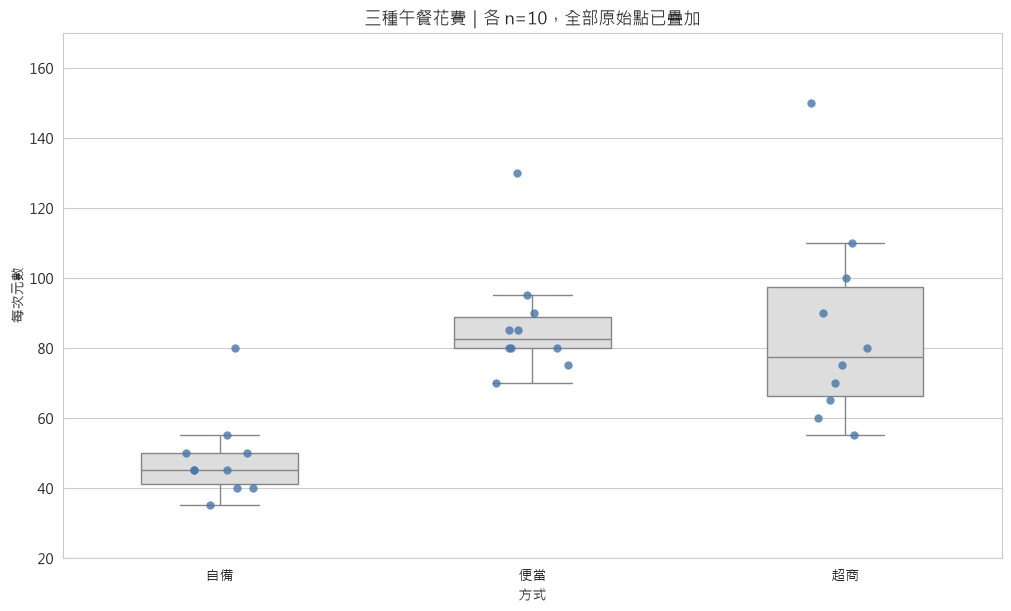

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	fig,ax=plt.subplots(figsize=(10,6),layout='constrained')
	sns.boxplot(data=df,x='方式',y='金額',order=order,color='#DDDDDD',
				whis=1.5,showfliers=False,width=0.5,ax=ax)
	np.random.seed(42)  # 只固定左右抖動，原始金額不變。
	sns.stripplot(data=df,x='方式',y='金額',order=order,color='#4477AA',
				jitter=0.12,alpha=0.8,size=6,ax=ax)
	ax.set(title='三種午餐花費｜各 n=10，全部原始點已疊加',xlabel='方式',ylabel='每次元數',ylim=(20,170))
	plt.show()

### 範例：兩家超商不同時段分面看

資料：[datasets/16_超商結帳等候.csv](datasets/16_超商結帳等候.csv)  
獨立程式：[examples/16_兩家超商不同時段分面看.py](examples/16_兩家超商不同時段分面看.py)  

店長想看兩家店早上與傍晚是否不同，用分面讓每店有自己的小圖，又保留共同尺度。讀者可以先看店內，再看店間，而不是一次在一個圖框找很多顏色。

**一列代表：** 一筆完成結帳的等候時間，記門市與時段。  
**範圍、單位與樣本：** 兩店各兩時段，每組10筆，共40筆，從排隊至輪到結帳計時。

In [53]:
import pandas as pd

df = pd.read_csv("./datasets/超商結帳等候.csv", encoding="utf-8-sig")
# df
shops=['車站店','社區店']
periods=['早上','傍晚']
table=df.groupby(['門市','時段'])['分鐘'].agg(n='size',中位數='median')

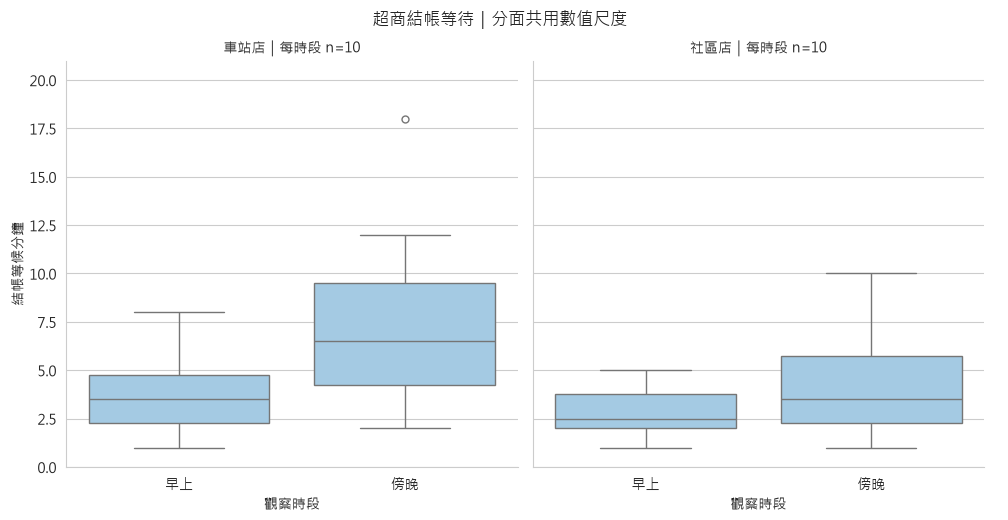

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
	g=sns.catplot(data=df,x='時段',y='分鐘',col='門市',kind='box',
              order=periods,col_order=shops,color='#99CCEE',whis=1.5,
              sharey=True,height=5,aspect=1)
	g.set_axis_labels('觀察時段','結帳等候分鐘')
	g.set_titles('{col_name}｜每時段 n=10')
	g.set(ylim=(0,21))
	g.figure.suptitle('超商結帳等待｜分面共用數值尺度',y=1.03)
	plt.show()